# Código. Análisis Poblacional de Registros Electrofisiológicos   
### Daniel Yedra Cázares
### Instituto de Fisiología Celular, UNAM

## Tabla de contenidos:
[1. Introducción](#introduction)

[2. Mitigación errores ](#EM)

[2.1. Ventanas](#Vent)

[2.2. Tapers](#Tap)

[2.3. Wavelets](#Wav)

## Introducción 

El objetivo de este cuaderno es ayudar a entendimientos de herramientas para el análisis y afianzar conceptos con ejemplos gráficos. 

### Inicializar el cuaderno

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram, windows
from scipy.signal.windows import dpss
from scipy.signal import get_window
from scipy.signal import windows, spectrogram
from scipy.special import legendre
from scipy.integrate import quad
import scipy.sparse as sparse
from scipy.sparse.linalg import eigs
from scipy.special import pro_ang1
from scipy.signal import windows


In [3]:
!pip install --upgrade pip


> **Explicación breve:** Esta celda centraliza todas las dependencias usadas en el notebook para que las importaciones no se repitan en cada bloque.


In [2]:
%matplotlib inline 



%config InlineBackend.figure_formats = {'png', 'retina'} 
plt.rcParams['axes.labelsize'] = 18 
plt.rcParams['axes.titlesize'] = 20 
plt.rcParams['font.size'] = 16 
plt.rcParams['lines.linewidth'] = 1.6


> **Explicación breve:**  Genera figuras o gráficos con matplotlib.


## Mitigación de Errores

En esta seccion primero vamos a recordar como se ve una fuga espectral dado tamaño fijo de bins, ademas de ver los efectos de frontera que se generan.

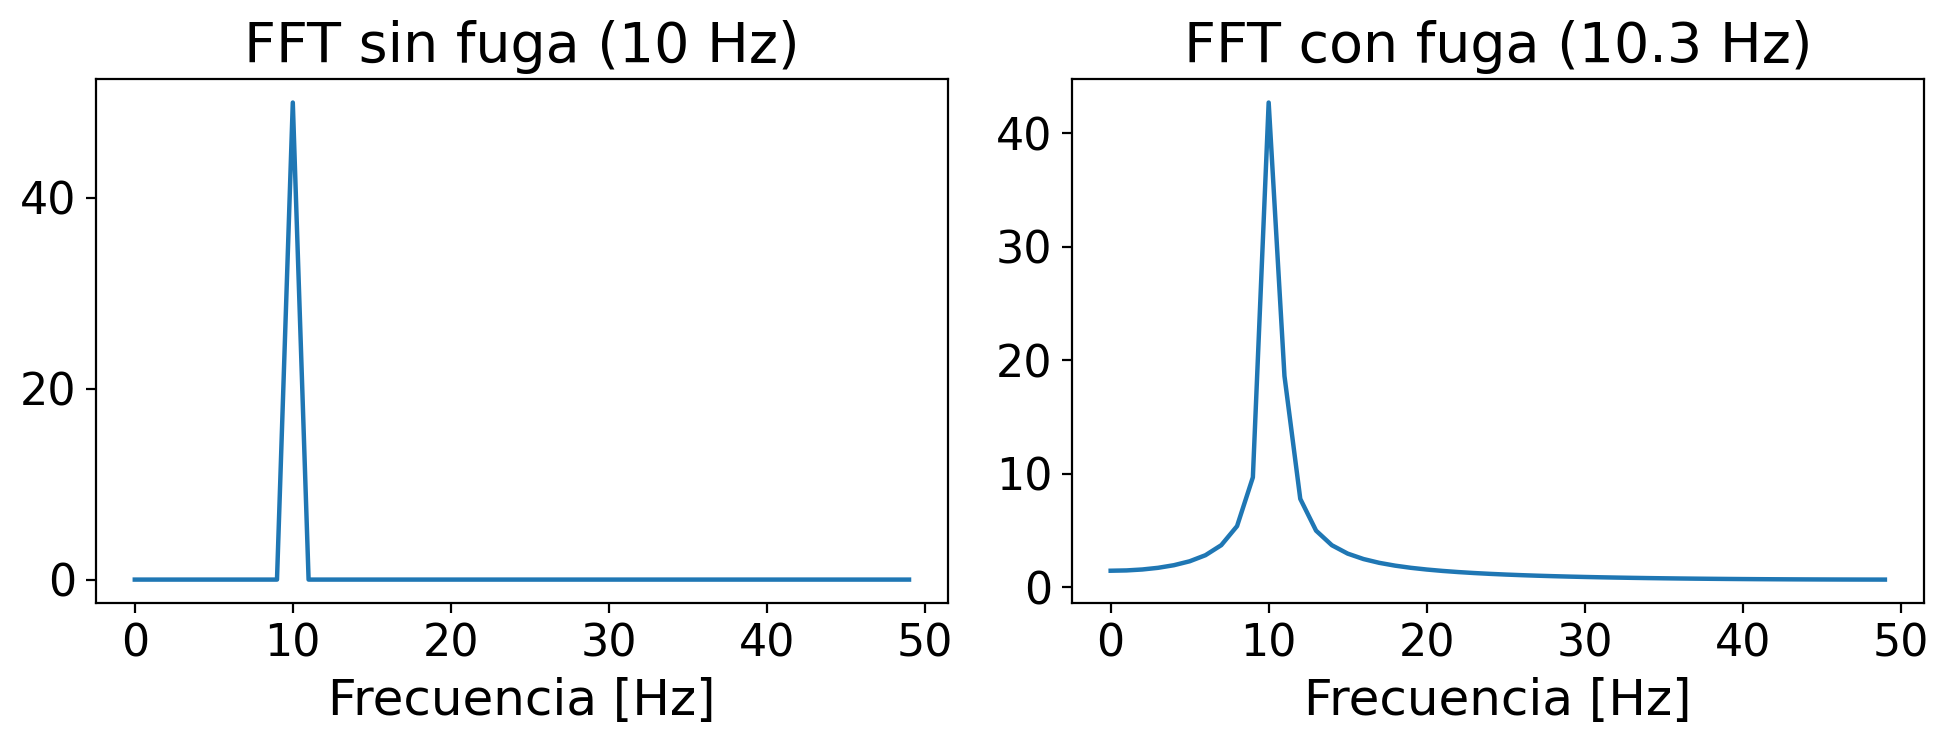

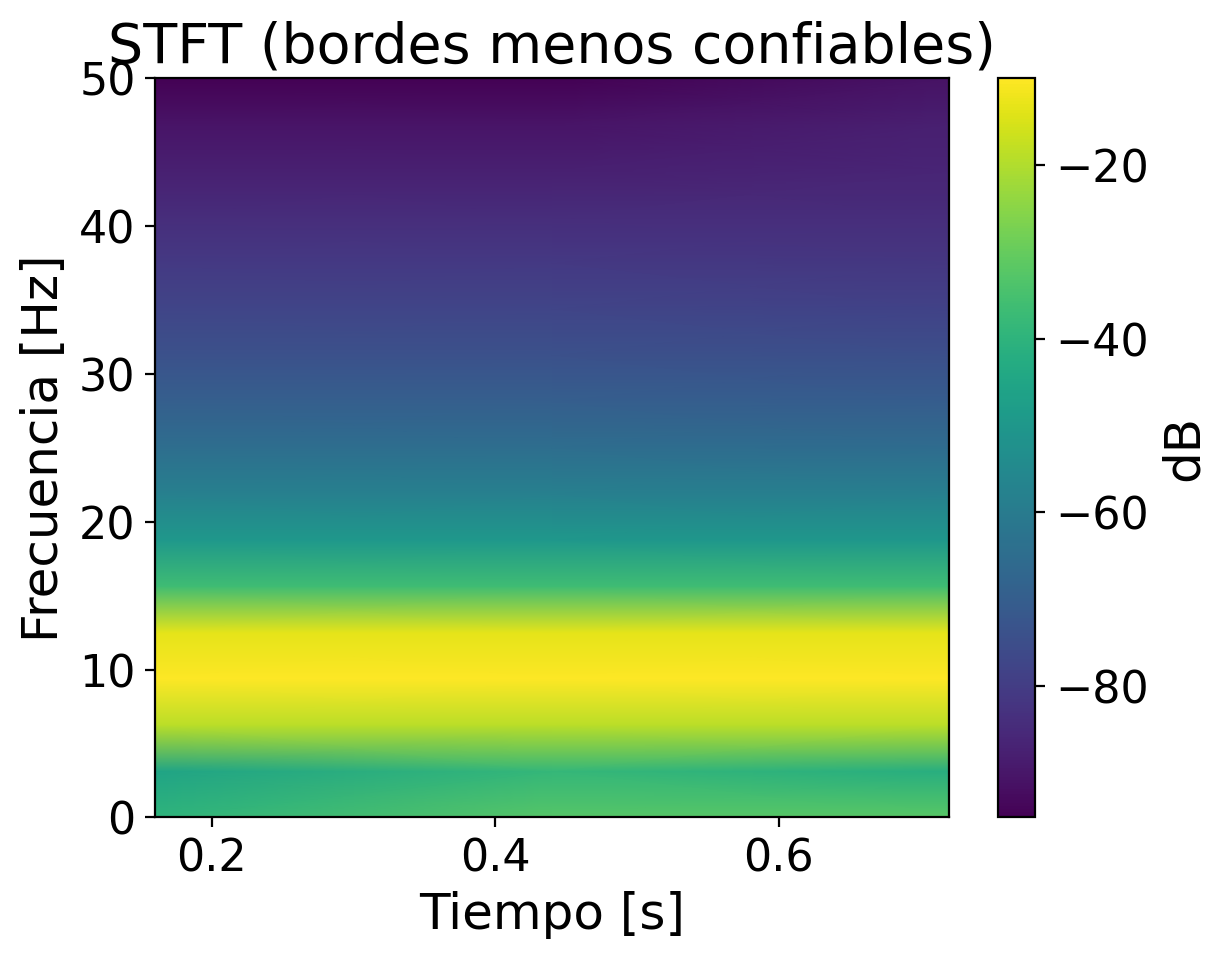

In [4]:
# --- Ejemplo 1: Fuga espectral ---
fs = 100
t = np.arange(0, 1, 1/fs)

signal_clean = np.sin(2*np.pi*10*t)     # 10 Hz exactos (bins de tamaño 10)
signal_leak  = np.sin(2*np.pi*10.3*t)   # 10.3 Hz -> no entero

fft_clean = np.abs(np.fft.fft(signal_clean))
fft_leak = np.abs(np.fft.fft(signal_leak))
freqs = np.fft.fftfreq(len(t), 1/fs)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(freqs[:len(freqs)//2], fft_clean[:len(freqs)//2])
plt.title("FFT sin fuga (10 Hz)") #Toda la energía de centra en el bin
plt.xlabel("Frecuencia [Hz]")# La energía se dispersa al no se multiplo de la frecuencia

plt.subplot(1,2,2)
plt.plot(freqs[:len(freqs)//2], fft_leak[:len(freqs)//2])
plt.title("FFT con fuga (10.3 Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.tight_layout()
plt.show()

# --- Ejemplo 2: Efectos de frontera con STFT ---
f, t_stft, Sxx = spectrogram(signal_clean, fs=fs, window='hann', nperseg=32)
plt.figure()
plt.pcolormesh(t_stft, f, 10*np.log10(Sxx), shading='gouraud')
plt.title("STFT (bordes menos confiables)")
plt.ylabel("Frecuencia [Hz]")
plt.xlabel("Tiempo [s]")
plt.colorbar(label="dB")
plt.show()


> **Explicación breve:** Este bloque es usado para mostar gráficamente la fuga espectral y la importancia de los bins.

Ahora veremos algunos métodos para reducir lo anterior

### Ventanas

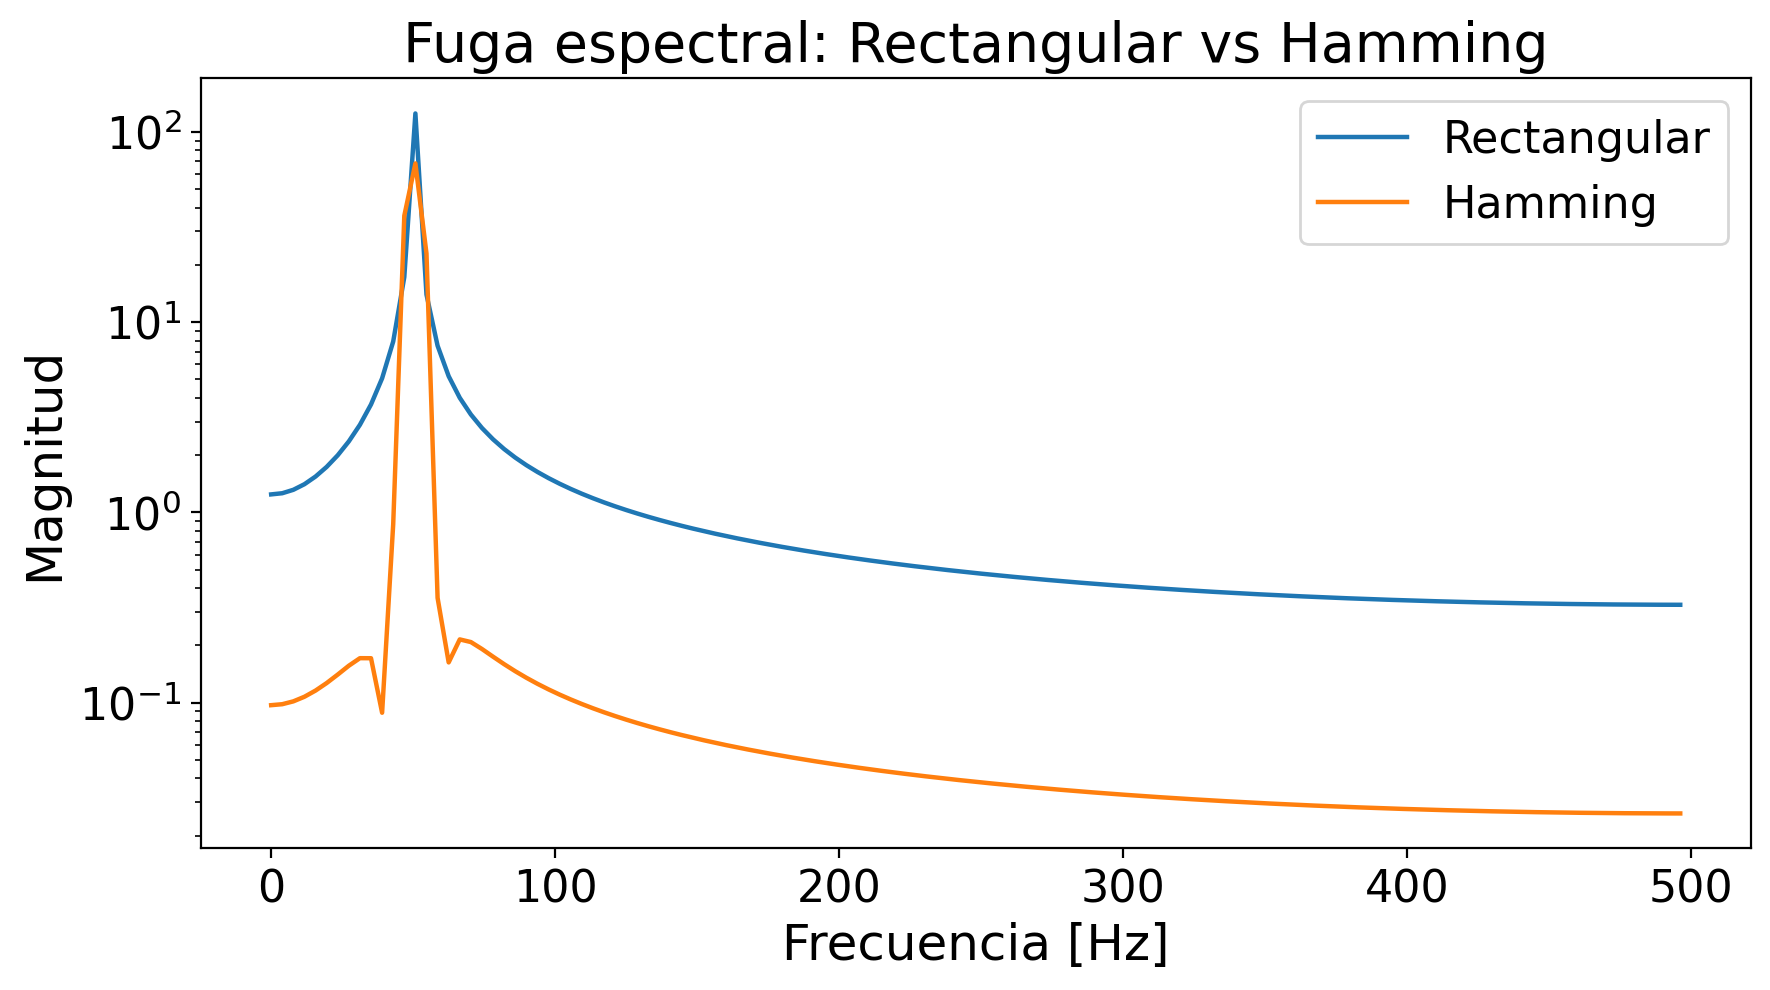

In [6]:
# Parámetros
fs = 1000   # frecuencia de muestreo
N = 256     # número de muestras


t = np.arange(N) / fs

# Señal: seno de 50.3 Hz (desalineado con los bins de la DFT)
x = np.sin(2 * np.pi * 50.3 * t)

# Ventanas
rect = np.ones(N)                # rectangular
hamming = get_window("hamming", N)

# Aplicar ventanas
x_rect = x * rect
x_hamming = x * hamming

# Espectros
X_rect = np.abs(np.fft.fft(x_rect))[:N//2]
X_hamming = np.abs(np.fft.fft(x_hamming))[:N//2]
freqs = np.fft.fftfreq(N, 1/fs)[:N//2]

plt.figure(figsize=(10,5))
plt.semilogy(freqs, X_rect, label="Rectangular")
plt.semilogy(freqs, X_hamming, label="Hamming")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Fuga espectral: Rectangular vs Hamming")
plt.legend()
plt.show()


> **Explicación breve:** Este bloque es para ejemplificar la diferencia entre ventanas (como ejemplo tomamos solo 2)

### Tapers

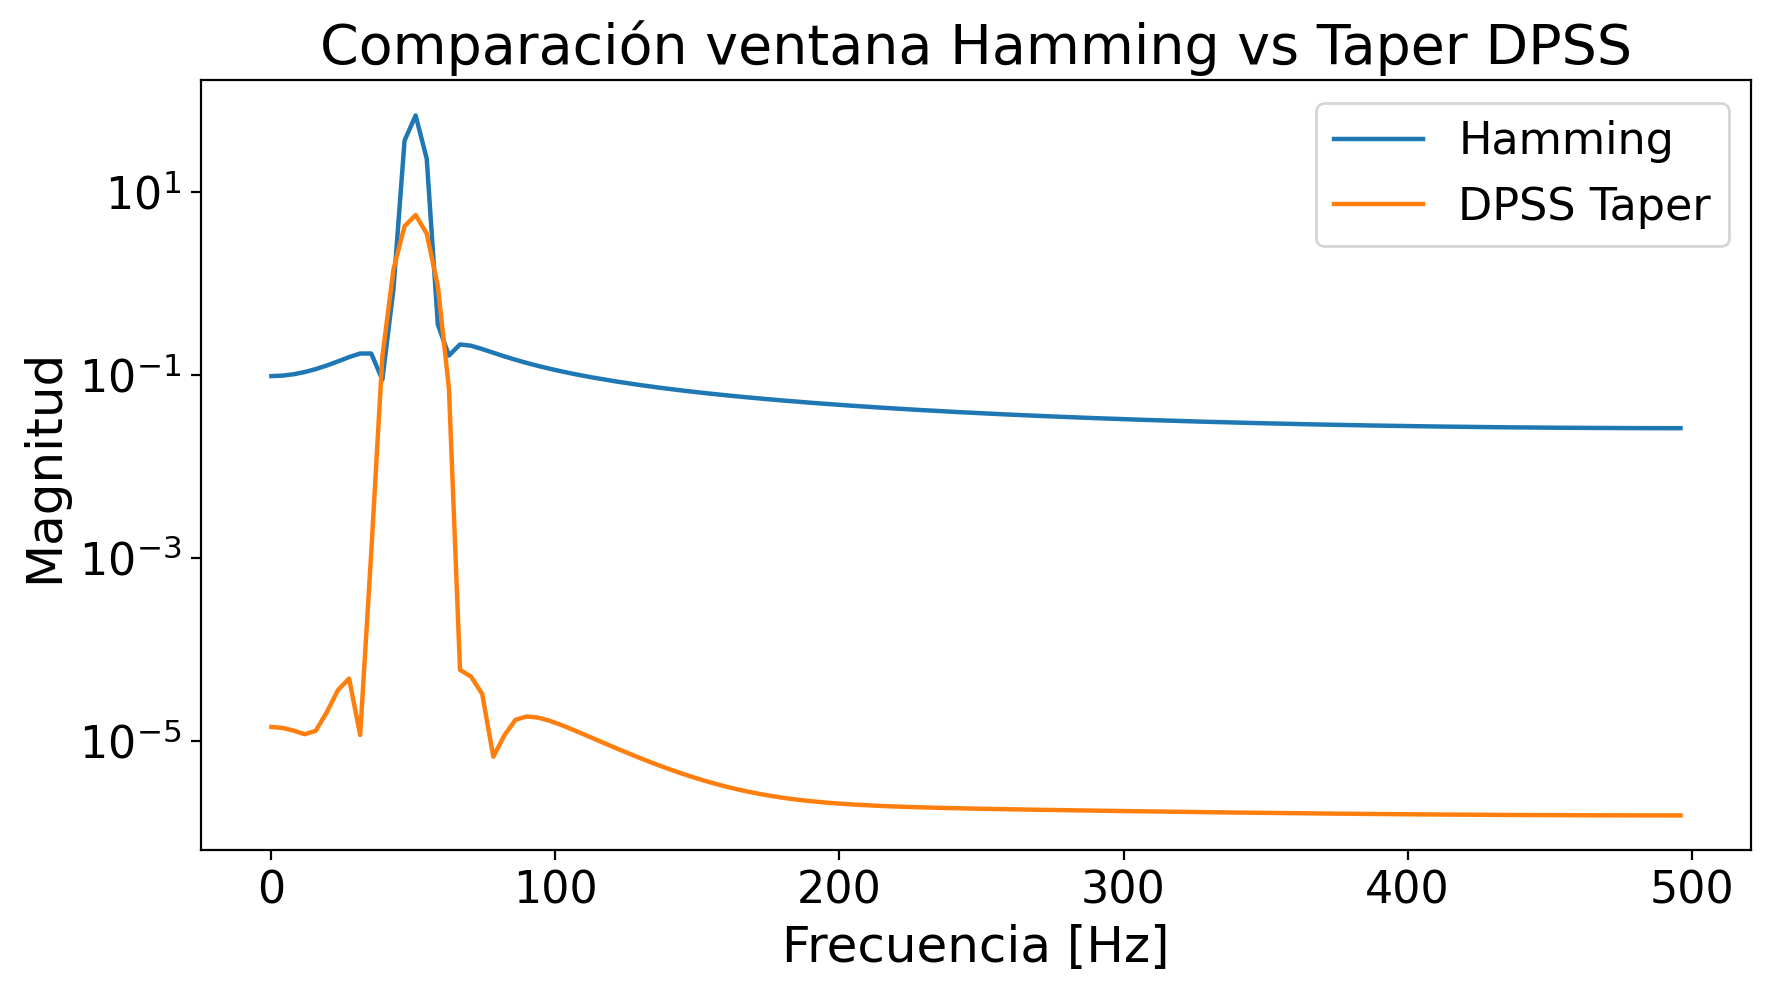

In [7]:
# Crear un taper DPSS
NW = 4  # ancho de banda normalizado
taper = dpss(N, NW, Kmax=1)[0]  # primer taper

# Señal con taper
x_taper = x * taper
X_taper = np.abs(np.fft.fft(x_taper))[:N//2]

plt.figure(figsize=(10,5))
plt.semilogy(freqs, X_hamming, label="Hamming")
plt.semilogy(freqs, X_taper, label="DPSS Taper")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Comparación ventana Hamming vs Taper DPSS")
plt.legend()
plt.show()


> **Explicación breve:** Este bloque como el anterior es para ver la diferencia entre una ventana común y el DPSS (el cual se explica en el apendice del texto)

### Multitapers (Thomson)

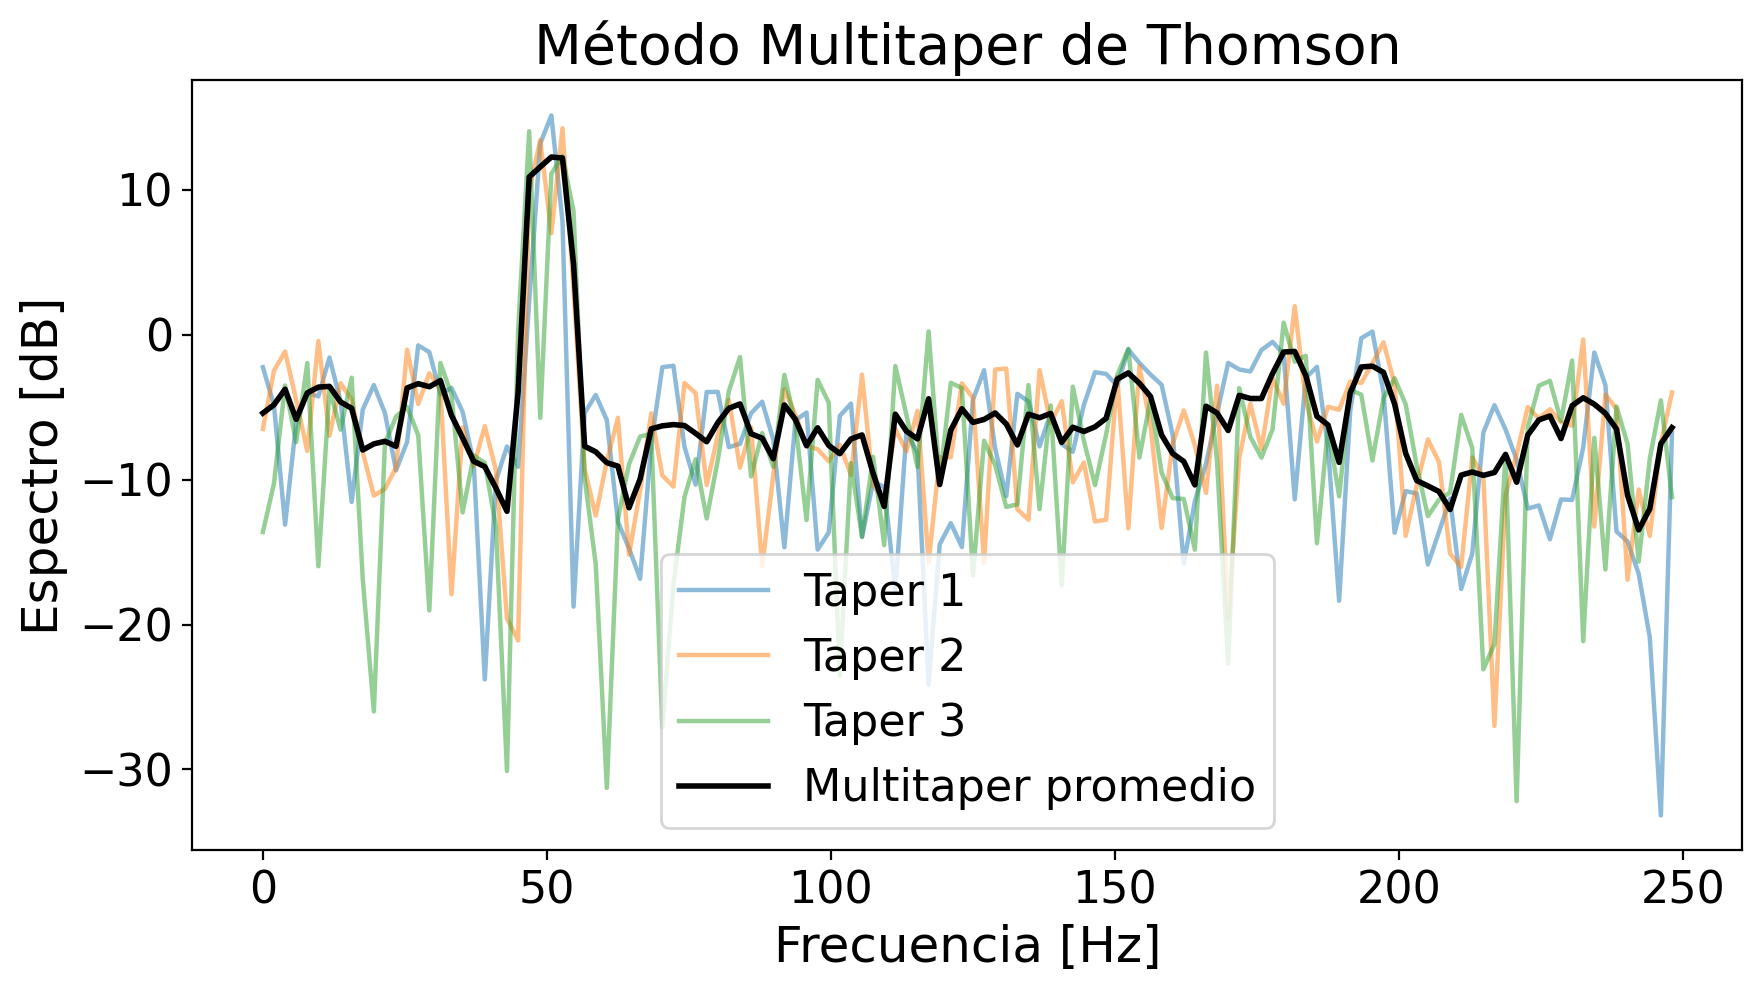

In [8]:
# Parámetros
fs = 500
N = 256
t = np.arange(N)/fs
x = np.sin(2*np.pi*50.3*t) + 0.5*np.random.randn(N)  # señal con ruido

# Generar 3 DPSS tapers
NW = 3
K = 3
tapers = dpss(N, NW, Kmax=K)

# Calcular espectros para cada taper
freqs = np.fft.fftfreq(N, 1/fs)[:N//2]
spectra = []
for k in range(K):
    x_taper = x * tapers[k]
    Xk = np.fft.fft(x_taper)[:N//2]
    spectra.append(np.abs(Xk)**2)

# Promediar
S_mt = np.mean(spectra, axis=0)

# Graficar
plt.figure(figsize=(10,5))
for k, Sk in enumerate(spectra):
    plt.plot(freqs, 10*np.log10(Sk), alpha=0.5, label=f"Taper {k+1}")
plt.plot(freqs, 10*np.log10(S_mt), 'k', linewidth=2, label="Multitaper promedio")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Espectro [dB]")
plt.title("Método Multitaper de Thomson")
plt.legend()
plt.show()


> **Explicación breve:** Este bloque de código srive para ver el funcionamiento del método multitaper, en especifico con DPSS

Ya vimos antes varios ejemplos donde ocupamos DPSS, de modo que vamos a profundizar un poco en como se obtiene, para esto el siguiente código complementa el ejercicio con los diferentes métodos usados.

En particular este primero es con la EDO asociada a este

Parámetro de concentración c = 6.283


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


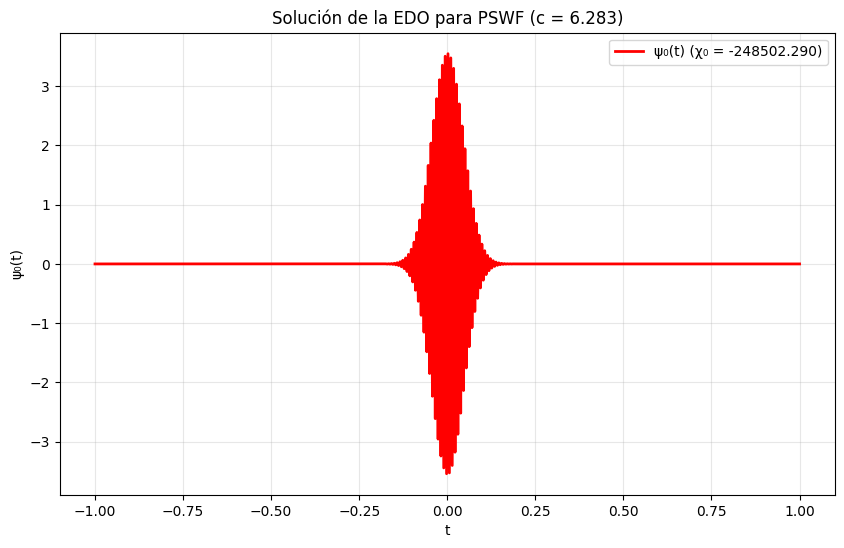


Resultados para c = 6.283:
Autovalor χ₀: -248502.289810
Norma de ψ₀: 1.000000
Valor en t=0: ψ₀(0) = 3.549557
Error en comparación con SciPy: operands could not be broadcast together with shapes (500,2) (500,) (500,2) 


In [2]:
T = 2.0          # Duración del intervalo [-T/2, T/2] -> [-1, 1]
Omega = 2 * np.pi  # Ancho de banda angular
c = Omega * T / 2  # Parámetro de concentración c = ΩT/2 = 2π
print(f"Parámetro de concentración c = {c:.3f}")

# =============================================================================
# DISCRETIZACIÓN
# =============================================================================
N = 500  # Número de puntos de discretización
t = np.linspace(-1, 1, N)  # Dominio normalizado [-1, 1]
dt = t[1] - t[0]  # Espaciado entre puntos

# =============================================================================
# CONSTRUCCIÓN DEL OPERADOR DE LA EDO
# =============================================================================
# La EDO es: d/dt[(1-t²)du/dt] + (χ - c²t²)u = 0

# 1. Coeficientes de la derivada primera
coeff1 = 1 - t**2

# 2. Construir matriz para el operador d/dt[coeff1 * du/dt]
# Usamos diferencias finitas centradas

# Diagonal principal
main_diag = (-2 * coeff1) / dt**2

# Subdiagonales
off_diag = coeff1[:-1] / dt**2

# 3. Construir la matriz tridiagonal
D = sparse.diags([off_diag, main_diag, off_diag], [-1, 0, 1], shape=(N, N))

# 4. Añadir el término -c²t²
potential_term = -c**2 * t**2
D += sparse.diags([potential_term], [0])

# =============================================================================
# CONDICIONES DE FRONTERA (CORRECCIÓN)
# =============================================================================
# En lugar de intentar indexar la matriz dispersa, aplicamos condiciones
# de frontera de Dirichlet modificando directamente las filas correspondientes

# Convertir a formato CSR para manipulación más fácil
D_csr = D.tocsr()

# Aplicar condiciones de frontera de Dirichlet (u(-1) = u(1) = 0)
# Para el primer punto (t = -1)
D_csr[0, 0] = 1.0
D_csr[0, 1:] = 0.0

# Para el último punto (t = 1)
D_csr[-1, -1] = 1.0
D_csr[-1, :-1] = 0.0

# El lado derecho será 0 para estas ecuaciones
# (Esto implementa u(-1) = 0 y u(1) = 0)

# =============================================================================
# RESOLVER EL PROBLEMA DE AUTOVALORES
# =============================================================================
# Resolver D * ψ = χ * ψ para los 4 autovalores más pequeños
eigenvals, eigenvecs = eigs(D_csr, k=4, which='SR')  # SR = Smallest Real part

# Seleccionar el autovector con el autovalor real más pequeño (ψ₀)
idx_smallest = np.argmin(np.real(eigenvals))
chi_0 = eigenvals[idx_smallest]
psi0_func = np.real(eigenvecs[:, idx_smallest])

# =============================================================================
# NORMALIZACIÓN Y POST-PROCESAMIENTO
# =============================================================================
# Asegurar que la función sea positiva en el centro
if psi0_func[len(psi0_func)//2] < 0:
    psi0_func *= -1

# Normalizar para que ∫ψ₀²dt = 1 en [-1, 1]
norm = np.sqrt(np.trapz(psi0_func**2, t))
psi0_func /= norm

# =============================================================================
# VISUALIZACIÓN
# =============================================================================
plt.figure(figsize=(10, 6))
plt.plot(t, psi0_func, 'r-', linewidth=2, label=f'ψ₀(t) (χ₀ = {np.real(chi_0):.3f})')
plt.title(f'Solución de la EDO para PSWF (c = {c:.3f})')
plt.xlabel('t')
plt.xlabel('t')
plt.ylabel('ψ₀(t)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =============================================================================
# INFORMACIÓN ADICIONAL
# =============================================================================
print(f"\nResultados para c = {c:.3f}:")
print(f"Autovalor χ₀: {np.real(chi_0):.6f}")
print(f"Norma de ψ₀: {np.trapz(psi0_func**2, t):.6f}")
print(f"Valor en t=0: ψ₀(0) = {psi0_func[len(psi0_func)//2]:.6f}")

# =============================================================================
# COMPARACIÓN CON MÉTODO DIRECTO (SCIPY) - OPCIONAL
# =============================================================================
try:
    
    # Calcular PSWF usando scipy para comparar
    psi0_scipy = np.array([pro_ang1(0, 0, c, t_val) for t_val in t])
    norm_scipy = np.sqrt(np.trapz(psi0_scipy**2, t))
    psi0_scipy /= norm_scipy
    
    # Graficar comparación
    plt.figure(figsize=(10, 6))
    plt.plot(t, psi0_func, 'r-', linewidth=2, label='EDO')
    plt.plot(t, psi0_scipy, 'b--', linewidth=2, label='SciPy')
    plt.title(f'Comparación: EDO vs SciPy (c = {c:.3f})')
    plt.xlabel('t')
    plt.ylabel('ψ₀(t)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # Calcular error
    error = np.sqrt(np.trapz((psi0_func - psi0_scipy)**2, t))
    print(f"Error RMS vs SciPy: {error:.6f}")
    
except ImportError:
    print("SciPy no disponible para comparación")
except Exception as e:
    print(f"Error en comparación con SciPy: {e}")


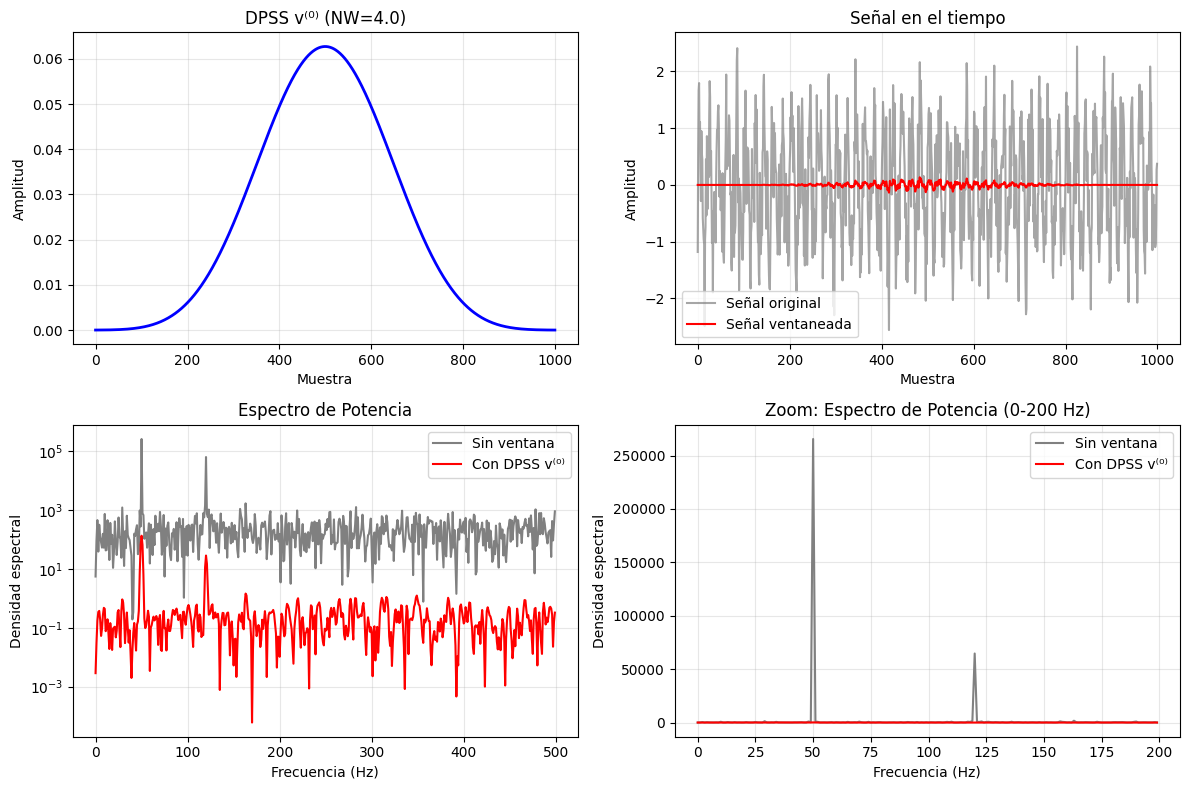

In [9]:
# Parámetros
N = 1000        # Longitud de la señal y del taper
NW = 4.0        # Producto tiempo-ancho de banda
n_tapers = 1    # Solo queremos el primer taper

# Generar el primer DPSS (v⁽⁰⁾)
tapers = windows.dpss(N, NW, n_tapers)
v0 = tapers[0]  # Primer DPSS

# Generar una señal de ejemplo (ruido blanco + tonos)
t = np.linspace(0, 1, N)
signal = (np.sin(2 * np.pi * 50 * t) + 
          0.5 * np.sin(2 * np.pi * 120 * t) +
          np.random.randn(N) * 0.5)

# Aplicar el taper a la señal
signal_tapered = signal * v0

# Calcular el periodograma (estimación espectral)
freqs = np.fft.rfftfreq(N, d=1/N)
psd_tapered = np.abs(np.fft.rfft(signal_tapered))**2
psd_original = np.abs(np.fft.rfft(signal))**2

# Visualización
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(v0, 'b-', linewidth=2)
plt.title(f'DPSS v⁽⁰⁾ (NW={NW})')
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(signal, 'gray', alpha=0.7, label='Señal original')
plt.plot(signal_tapered, 'r-', linewidth=1.5, label='Señal ventaneada')
plt.title('Señal en el tiempo')
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.semilogy(freqs[:500], psd_original[:500], 'gray', label='Sin ventana')
plt.semilogy(freqs[:500], psd_tapered[:500], 'r-', label='Con DPSS v⁽⁰⁾')
plt.title('Espectro de Potencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(freqs[:200], psd_original[:200], 'gray', label='Sin ventana')
plt.plot(freqs[:200], psd_tapered[:200], 'r-', label='Con DPSS v⁽⁰⁾')
plt.title('Zoom: Espectro de Potencia (0-200 Hz)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


> **Explicación breve:** En este bloque de código vemos como el uso de un DPSS (el vector propio V^{0}) nos cambia la señal original.


Usando 7 tapers para NW=4.0
Autovalores: [1.         0.99999997 0.99999879 0.99996756 0.99941019 0.99250534
 0.93665556]


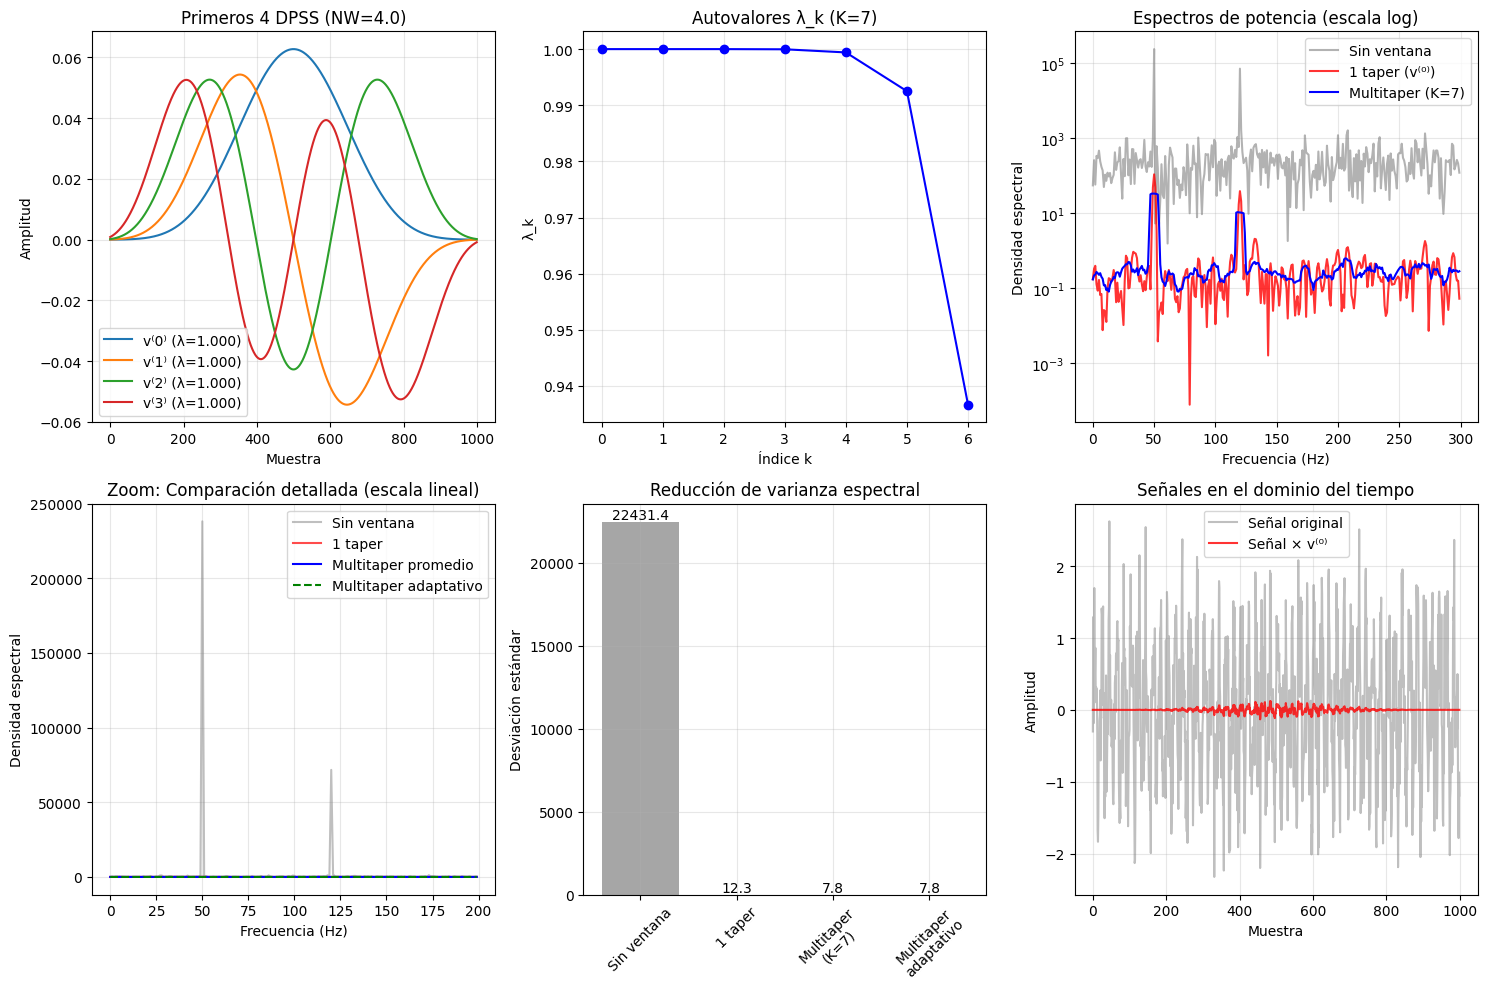


=== RESULTADOS ===
Parámetros: N=1000, NW=4.0, K=7

Autovalores:
  λ_0 = 1.000000
  λ_1 = 1.000000
  λ_2 = 0.999999
  λ_3 = 0.999968
  λ_4 = 0.999410
  λ_5 = 0.992505
  λ_6 = 0.936656

Varianza relativa (respecto a sin ventana):
  - 1 taper (v⁽⁰⁾): 0.001
  - Multitaper promedio: 0.000
  - Multitaper adaptativo: 0.000

Reducción de varianza:
  - 1 taper: 99.9%
  - Multitaper: 100.0%


In [3]:

# Parámetros
N = 1000        # Longitud de la señal y del taper
NW = 4.0        # Producto tiempo-ancho de banda

# Generar una señal de ejemplo (ruido blanco + tonos)
t = np.linspace(0, 1, N)
signal = (np.sin(2 * np.pi * 50 * t) + 
          0.5 * np.sin(2 * np.pi * 120 * t) +
          np.random.randn(N) * 0.5)

# Calcular frecuencias para FFT
freqs = np.fft.rfftfreq(N, d=1/N)
psd_original = np.abs(np.fft.rfft(signal))**2

# =============================================================================
# 1. USO COMO SIMPLE TAPER (solo v⁽⁰⁾)
# =============================================================================
# Generar el primer DPSS (v⁽⁰⁾)
tapers_single = windows.dpss(N, NW, 1)
v0 = tapers_single[0]  # Primer DPSS

# Aplicar el taper a la señal
signal_tapered = signal * v0
psd_tapered = np.abs(np.fft.rfft(signal_tapered))**2

# =============================================================================
# 2. USO COMO MULTITAPER (K tapers)
# =============================================================================
# Generar múltiples DPSS - FORMA CORRECTA
K = int(2 * NW - 1)  # Número de tapers a usar
tapers, eigenvalues = windows.dpss(N, NW, K, return_ratios=True)

print(f"Usando {K} tapers para NW={NW}")
print(f"Autovalores: {eigenvalues}")

# Método 1: Promedio simple
psd_multitaper = np.zeros(len(freqs))
for i in range(K):
    signal_tapered_i = signal * tapers[i]
    psd_i = np.abs(np.fft.rfft(signal_tapered_i))**2
    psd_multitaper += psd_i / K

# Método 2: Pesos adaptativos (usando autovalores como pesos)
psd_adaptive = np.zeros(len(freqs))
for i in range(K):
    signal_tapered_i = signal * tapers[i]
    psd_i = np.abs(np.fft.rfft(signal_tapered_i))**2
    psd_adaptive += eigenvalues[i] * psd_i
psd_adaptive /= np.sum(eigenvalues)  # Normalizar

# =============================================================================
# VISUALIZACIÓN
# =============================================================================
plt.figure(figsize=(15, 10))

# 1. Mostrar los tapers
plt.subplot(2, 3, 1)
for i in range(min(4, K)):
    plt.plot(tapers[i], label=f'v⁽{i}⁾ (λ={eigenvalues[i]:.3f})')
plt.title(f'Primeros {min(4, K)} DPSS (NW={NW})')
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Autovalores
plt.subplot(2, 3, 2)
plt.plot(range(K), eigenvalues, 'bo-')
plt.title(f'Autovalores λ_k (K={K})')
plt.xlabel('Índice k')
plt.ylabel('λ_k')
plt.grid(True, alpha=0.3)

# 3. Comparación de espectros (escala logarítmica)
plt.subplot(2, 3, 3)
plt.semilogy(freqs[:300], psd_original[:300], 'gray', alpha=0.6, label='Sin ventana')
plt.semilogy(freqs[:300], psd_tapered[:300], 'r-', alpha=0.8, label='1 taper (v⁽⁰⁾)')
plt.semilogy(freqs[:300], psd_multitaper[:300], 'b-', label=f'Multitaper (K={K})')
plt.title('Espectros de potencia (escala log)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Comparación detallada (escala lineal)
plt.subplot(2, 3, 4)
plt.plot(freqs[:200], psd_original[:200], 'gray', alpha=0.5, label='Sin ventana')
plt.plot(freqs[:200], psd_tapered[:200], 'r-', alpha=0.7, label='1 taper')
plt.plot(freqs[:200], psd_multitaper[:200], 'b-', label='Multitaper promedio')
plt.plot(freqs[:200], psd_adaptive[:200], 'g--', label='Multitaper adaptativo')
plt.title('Zoom: Comparación detallada (escala lineal)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Reducción de varianza
plt.subplot(2, 3, 5)
freq_range = (40, 160)  # Rango alrededor de los tonos
idx_range = np.where((freqs >= freq_range[0]) & (freqs <= freq_range[1]))[0]

std_original = np.std(psd_original[idx_range])
std_tapered = np.std(psd_tapered[idx_range])
std_multitaper = np.std(psd_multitaper[idx_range])
std_adaptive = np.std(psd_adaptive[idx_range])

methods = ['Sin ventana', '1 taper', f'Multitaper\n(K={K})', 'Multitaper\nadaptativo']
std_values = [std_original, std_tapered, std_multitaper, std_adaptive]

bars = plt.bar(methods, std_values, alpha=0.7, 
               color=['gray', 'red', 'blue', 'green'])
plt.title('Reducción de varianza espectral')
plt.ylabel('Desviación estándar')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Añadir valores en las barras
for bar, value in zip(bars, std_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{value:.1f}', ha='center', va='bottom')

# 6. Señales en el tiempo
plt.subplot(2, 3, 6)
plt.plot(signal, 'gray', alpha=0.5, label='Señal original')
plt.plot(signal * tapers[0], 'r-', alpha=0.8, label='Señal × v⁽⁰⁾')
plt.title('Señales en el dominio del tiempo')
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# RESULTADOS NUMÉRICOS
# =============================================================================
print(f"\n=== RESULTADOS ===")
print(f"Parámetros: N={N}, NW={NW}, K={K}")
print(f"\nAutovalores:")
for i in range(K):
    print(f"  λ_{i} = {eigenvalues[i]:.6f}")

print(f"\nVarianza relativa (respecto a sin ventana):")
print(f"  - 1 taper (v⁽⁰⁾): {std_tapered/std_original:.3f}")
print(f"  - Multitaper promedio: {std_multitaper/std_original:.3f}")
print(f"  - Multitaper adaptativo: {std_adaptive/std_original:.3f}")

print(f"\nReducción de varianza:")
print(f"  - 1 taper: {(1 - std_tapered/std_original)*100:.1f}%")
print(f"  - Multitaper: {(1 - std_multitaper/std_original)*100:.1f}%")


> **Explicación breve:** Este bloque de código vemos el uso de varios DPSS


### Wavelets

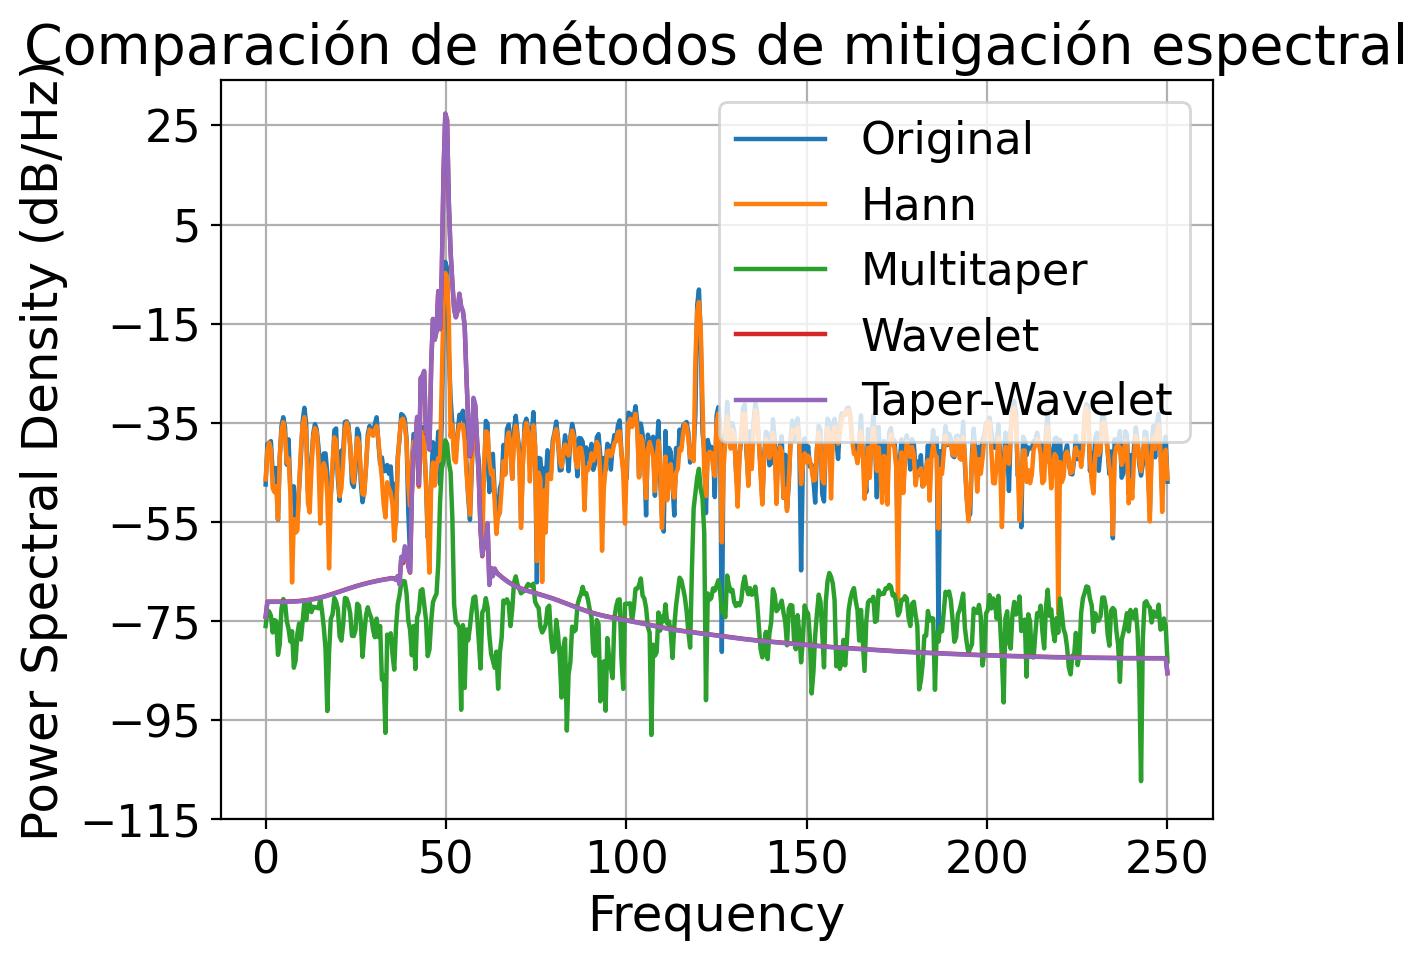

In [17]:
# Señal de prueba: suma de senoidales + ruido
fs = 500  # Hz
t = np.arange(0, 2, 1/fs)
signal = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t) + 0.2*np.random.randn(len(t))

# ---------- 1. Ventana clásica (Hann) ----------
hann_win = windows.hann(len(signal))
signal_hann = signal * hann_win

# ---------- 2. Multitaper (DPSS) ----------
tapers = dpss(len(signal), NW=4, Kmax=3)  # 3 tapers
signal_mt = np.mean([signal * taper for taper in tapers], axis=0)

# ---------- 3. Wavelet (Morlet construido a mano) ----------
def morlet_wavelet(t, f0=50, sigma=0.05):
    return np.exp(2j*np.pi*f0*t) * np.exp(-t**2/(2*sigma**2))

tw = np.linspace(-1, 1, len(signal))
morlet = morlet_wavelet(tw, f0=50, sigma=0.05)
# convolución
signal_wavelet = np.convolve(signal, np.real(morlet), mode='same')

# ---------- 4. Taper-Wavelet (Morlet * Hann) ----------
morlet_tapered = np.real(morlet) * hann_win
signal_tw = np.convolve(signal, morlet_tapered, mode='same')

# ---------- Espectros comparativos ----------
f, Pxx_signal = plt.psd(signal, NFFT=1024, Fs=fs, label='Original')
f, Pxx_hann = plt.psd(signal_hann, NFFT=1024, Fs=fs, label='Hann')
f, Pxx_mt = plt.psd(signal_mt, NFFT=1024, Fs=fs, label='Multitaper')
f, Pxx_wav = plt.psd(signal_wavelet, NFFT=1024, Fs=fs, label='Wavelet')
f, Pxx_tw = plt.psd(signal_tw, NFFT=1024, Fs=fs, label='Taper-Wavelet')

plt.legend()

plt.title("Comparación de métodos de mitigación espectral")
plt.show()


> **Explicación breve:** Este bloque de código nos muestra la comparacion de varios métodos de mitigacion


## Tiempo-frecuencia

ITPC para fases consistentes: 0.9547
ITPC para fases aleatorias: 0.1755


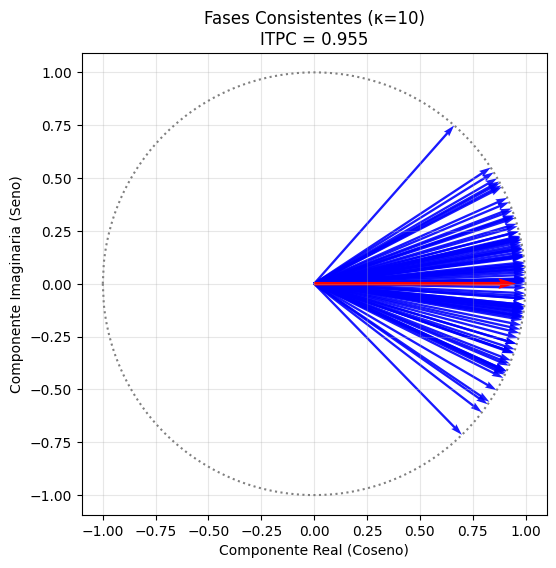

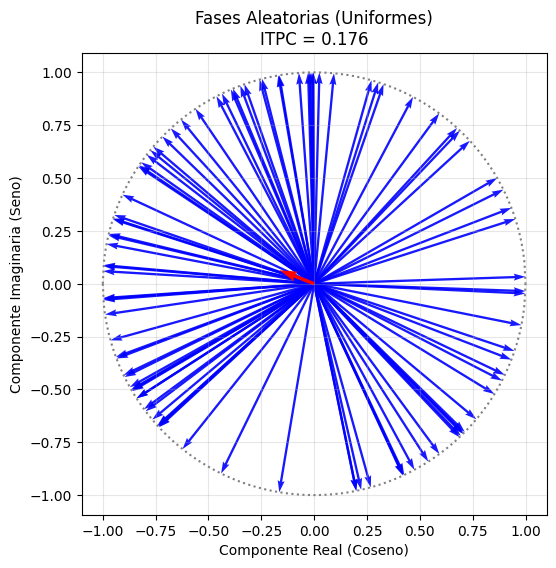

In [22]:

# Simulación: Datos de fase para 100 ensayos en un punto de tiempo
np.random.seed(42)  # Para reproducibilidad
N_trials = 100

# Caso 1: Fases altamente consistentes (ITPC ~1)
phase_concentrated = np.random.vonmises(mu=0, kappa=10, size=N_trials)

# Caso 2: Fases aleatorias (ITPC ~0)
phase_random = np.random.uniform(low=-np.pi, high=np.pi, size=N_trials)

def calculate_itpc(phases):
    
    # Convertir cada fase a un vector complejo en el círculo unitario
    vectors = np.exp(1j * phases)
    
    # Calcular el vector promedio
    mean_vector = np.mean(vectors)
    
    # La ITPC es la magnitud (longitud) de ese vector promedio
    itpc = np.abs(mean_vector)
    
    return itpc, mean_vector

# Calcular ITPC para ambos casos
itpc_high, mean_vec_high = calculate_itpc(phase_concentrated)
itpc_low, mean_vec_low = calculate_itpc(phase_random)

print(f"ITPC para fases consistentes: {itpc_high:.4f}")
print(f"ITPC para fases aleatorias: {itpc_low:.4f}")

# Visualización
def plot_phases(phases, title, itpc_value):
    plt.figure(figsize=(6, 6))
    
    # Plotear cada vector de fase
    for phi in phases:
        x = np.cos(phi)
        y = np.sin(phi)
        plt.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1, 
                   color='blue', alpha=0.9, width=0.005)
    
    # Plotear el vector promedio (ITPC)
    mean_vector = np.mean(np.exp(1j * phases))
    plt.quiver(0, 0, mean_vector.real, mean_vector.imag, angles='xy', 
               scale_units='xy', scale=1, color='red', linewidth=3)

    # Definir el rango de x
    x = np.linspace(-1, 1, 400)  # 400 puntos entre -1 y 1

    # Calcular los valores de y para la mitad superior e inferior
    y_upper = np.sqrt(1 - x**2)  # Mitad superior del círculo
    y_lower = -np.sqrt(1 - x**2) # Mitad inferior del círculo

    # Configurar el gráfico
    #plt.figure(figsize=(6, 6))
    plt.plot(x, y_upper, color='grey', linestyle='dotted' ,label='$y = \sqrt{1 - x^2}$')  # Mitad superior
    plt.plot(x, y_lower, color='grey', linestyle='dotted' ,label='$y = -\sqrt{1 - x^2}$') # Mitad inferior
    
    plt.xlim(-1.2, 1.2)
    plt.plot()
    plt.ylim(-1.2, 1.2)
    plt.gca().set_aspect('equal')
    plt.title(f'{title}\nITPC = {itpc_value:.3f}')
    plt.xlabel('Componente Real (Coseno)')
    plt.ylabel('Componente Imaginaria (Seno)')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')  # Misma escala en ambos ejes (importante para que se vea circular)
    #plt.legend()
    plt.show()

plot_phases(phase_concentrated, 'Fases Consistentes (κ=10)', itpc_high)
plot_phases(phase_random, 'Fases Aleatorias (Uniformes)', itpc_low)


> **Explicación breve:** Este bloque de código nos ayuda a ver gráficamente como se obtiene el ITPC


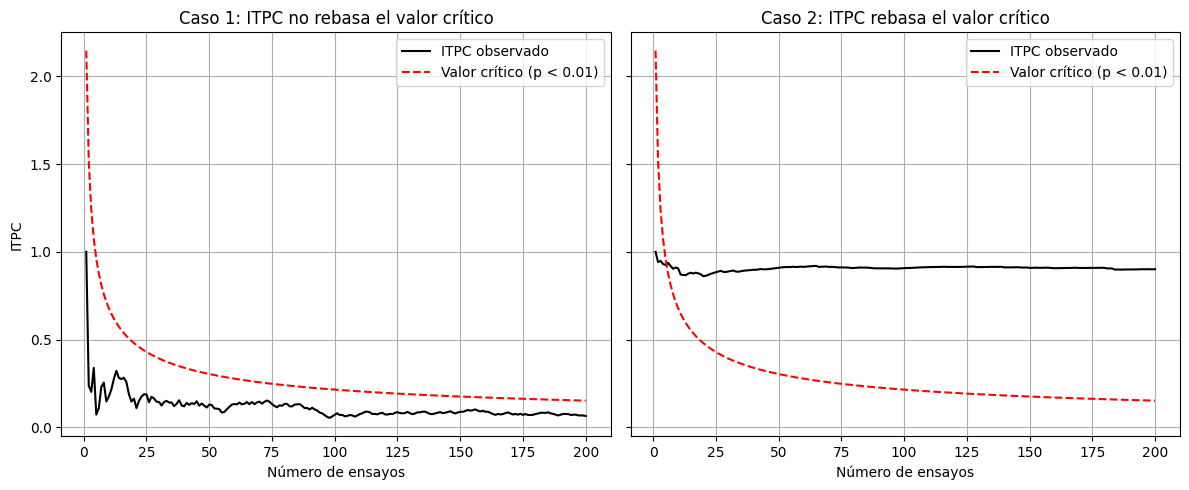

In [2]:

# -------------------------
# Función para ITPC
# -------------------------
def compute_itpc(phases):
    """Calcula ITPC acumulado a lo largo de los trials."""
    N = len(phases)
    itpc_values = []
    for n in range(1, N + 1):
        vec = np.exp(1j * phases[:n])
        itpc = np.abs(np.mean(vec))
        itpc_values.append(itpc)
    return np.array(itpc_values)

def itpc_critical(alpha, N):
    """Umbral crítico de significancia estadística (Rayleigh approx)."""
    return np.sqrt(-np.log(alpha) / N)

# -------------------------
# Simulación de fases
# -------------------------
np.random.seed(42)   # reproducibilidad
N_trials = 200
alpha = 0.01
trials = np.arange(1, N_trials + 1)

# Caso 1: fases aleatorias (no debería rebasar)
phases_random = np.random.uniform(0, 2*np.pi, N_trials)
itpc_random = compute_itpc(phases_random)

# Caso 2: fases con cierto alineamiento (sí debería rebasar)
preferred_phase = np.pi/4
phases_locked = preferred_phase + np.random.vonmises(mu=0, kappa=5, size=N_trials)
itpc_locked = compute_itpc(phases_locked)

# Umbral crítico para cada número de ensayos
crit_line = itpc_critical(alpha, trials)

# -------------------------
# Gráficas
# -------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Caso 1
axs[0].plot(trials, itpc_random, 'k-', label="ITPC observado")
axs[0].plot(trials, crit_line, 'r--', label="Valor crítico (p < 0.01)")
axs[0].set_title("Caso 1: ITPC no rebasa el valor crítico")
axs[0].set_xlabel("Número de ensayos")
axs[0].set_ylabel("ITPC")
axs[0].legend()
axs[0].grid(True)

# Caso 2
axs[1].plot(trials, itpc_locked, 'k-', label="ITPC observado")
axs[1].plot(trials, crit_line, 'r--', label="Valor crítico (p < 0.01)")
axs[1].set_title("Caso 2: ITPC rebasa el valor crítico")
axs[1].set_xlabel("Número de ensayos")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


> **Explicación breve:** Este nos ayuda a complementar el entendimiento del ITPC, usando hipotesis estadisiticas (enunciadas en el texto)

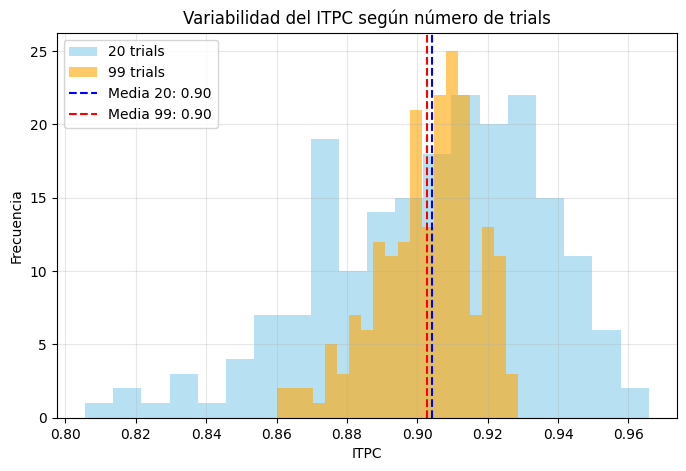

In [4]:
def compute_itpc(phases):
    return np.abs(np.mean(np.exp(1j * phases)))

# -------------------------
# Simulación
# -------------------------
np.random.seed(123)
N_reps = 200  # cuántas veces repetimos el muestreo
preferred_phase = np.pi/3

# Distribución con cierto alineamiento (von Mises ~ normal circular)
phases_all = preferred_phase + np.random.vonmises(mu=0, kappa=5, size=1000)

# Estimaciones con 20 trials
itpc_20 = [compute_itpc(np.random.choice(phases_all, 20, replace=False))
           for _ in range(N_reps)]

# Estimaciones con 99 trials
itpc_99 = [compute_itpc(np.random.choice(phases_all, 99, replace=False))
           for _ in range(N_reps)]

# -------------------------
# Gráfico comparativo
# -------------------------
plt.figure(figsize=(8,5))

plt.hist(itpc_20, bins=20, alpha=0.6, color="skyblue", label="20 trials")
plt.hist(itpc_99, bins=20, alpha=0.6, color="orange", label="99 trials")

plt.axvline(np.mean(itpc_20), color="blue", linestyle="--", label=f"Media 20: {np.mean(itpc_20):.2f}")
plt.axvline(np.mean(itpc_99), color="red", linestyle="--", label=f"Media 99: {np.mean(itpc_99):.2f}")

plt.title("Variabilidad del ITPC según número de trials")
plt.xlabel("ITPC")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


> **Explicación breve:** Este bloque de código nos muestra la variación que hay dependiendo del número de trials
